# Credit Card Fraud Detection Using Machine Learning

## Introduction

Credit card fraud detection is an important application of Machine Learning.
This project analyzes credit card transactions and identifies whether a
transaction is genuine or fraudulent.

## Problem Statement

Credit card fraud is a major problem in digital financial transactions.
The objective of this project is to develop a Machine Learning model
that can identify fraudulent transactions from genuine transactions.

## Objectives

- Analyze credit card transaction data
- Identify patterns associated with fraudulent transactions
- Handle highly imbalanced transaction classes
- Apply Machine Learning classification algorithms
- Evaluate model performance using multiple metrics
- Predict whether a transaction is genuine or fraudulent

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Imbalanced-learn
- Google Colab

In [40]:
import pandas as pd

df = pd.read_csv('/content/creditcard.csv')

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (284807, 31)


In [2]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [4]:
df['Class'].value_counts()

,count
Class,
0,284315
1,492


In [6]:
print(df['Class'].value_counts(normalize=True) * 100)

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


In [7]:
print(df['Class'].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


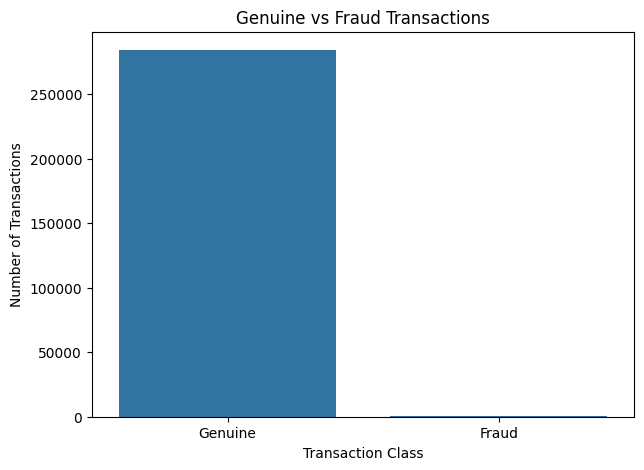

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))

sns.countplot(x='Class', data=df)

plt.title('Genuine vs Fraud Transactions')
plt.xlabel('Transaction Class')
plt.ylabel('Number of Transactions')
plt.xticks([0, 1], ['Genuine', 'Fraud'])

plt.show()

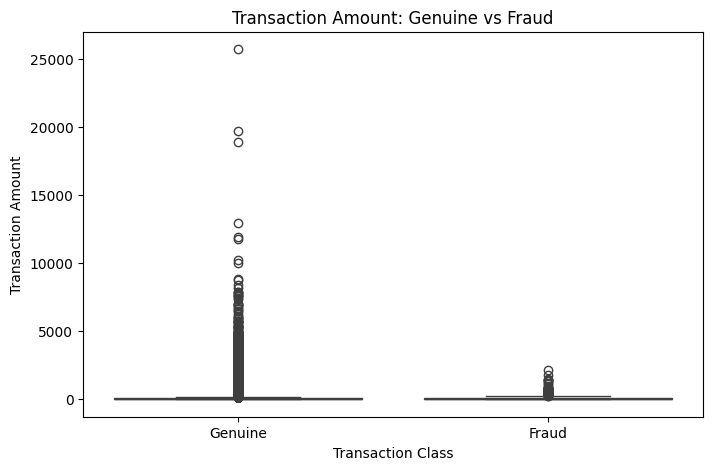

In [9]:
plt.figure(figsize=(8, 5))

sns.boxplot(x='Class', y='Amount', data=df)

plt.title('Transaction Amount: Genuine vs Fraud')
plt.xlabel('Transaction Class')
plt.ylabel('Transaction Amount')
plt.xticks([0, 1], ['Genuine', 'Fraud'])

plt.show()

In [10]:
df.groupby('Class')['Amount'].describe()

,count,mean,std,min,25%,50%,75%,max
Class,,,,,,,,
0,284315.0,88.291022,250.105092,0.0,5.65,22.00,77.05,25691.16
1,492.0,122.211321,256.683288,0.0,1.00,9.25,105.89,2125.87


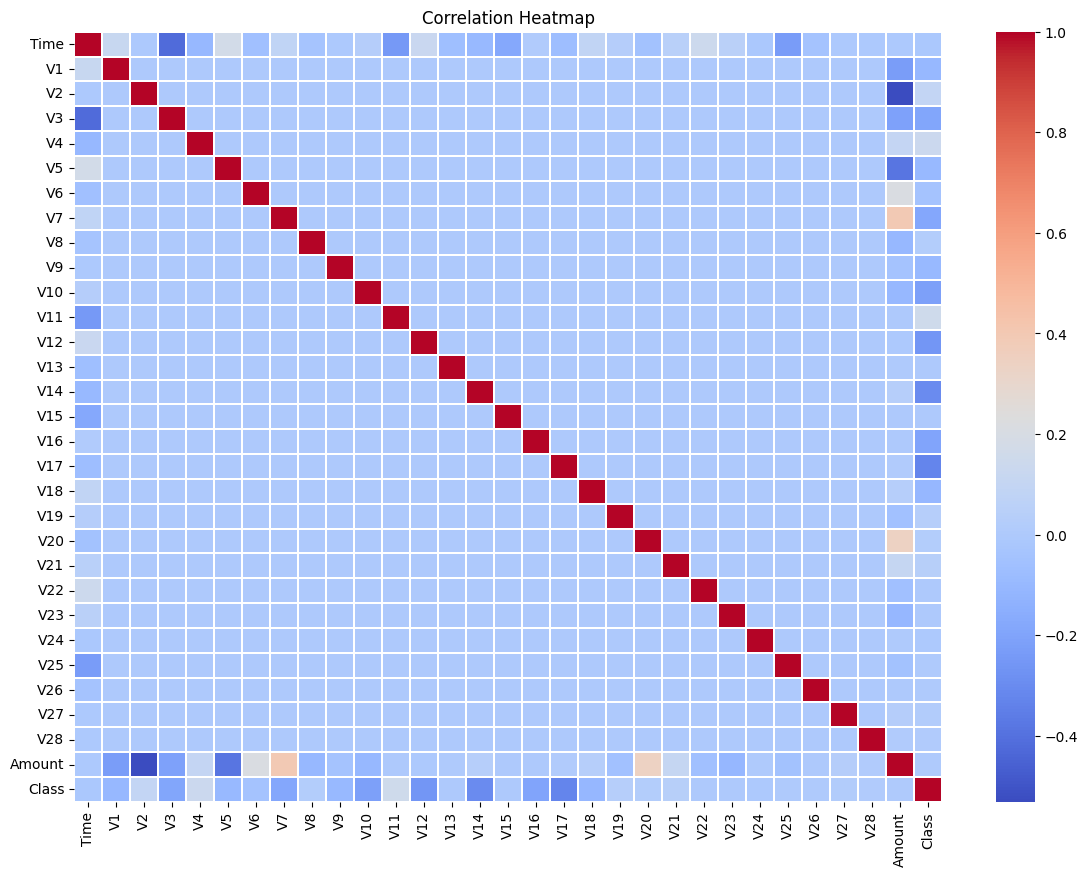

In [11]:
plt.figure(figsize=(14, 10))

correlation = df.corr()

sns.heatmap(
    correlation,
    cmap='coolwarm',
    linewidths=0.1
)

plt.title('Correlation Heatmap')
plt.show()

In [12]:
correlation_with_class = df.corr()['Class'].sort_values(ascending=False)

print(correlation_with_class)

Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64


In [13]:
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("Dataset shape:", df.shape)

Missing values: 0
Duplicate rows: 1081
Dataset shape: (284807, 31)


In [14]:
# Remove duplicate rows
df = df.drop_duplicates()

print("Dataset shape after removing duplicates:", df.shape)
print("Remaining duplicate rows:", df.duplicated().sum())

Dataset shape after removing duplicates: (283726, 31)
Remaining duplicate rows: 0


In [15]:
# Separate features and target
X = df.drop('Class', axis=1)
y = df['Class']

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (283726, 30)
Target shape: (283726,)


In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (226980, 30)
X_test: (56746, 30)
y_train: (226980,)
y_test: (56746,)


In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = X_train.copy()
X_test = X_test.copy()

X_train[['Time', 'Amount']] = scaler.fit_transform(
    X_train[['Time', 'Amount']]
)

X_test[['Time', 'Amount']] = scaler.transform(
    X_test[['Time', 'Amount']]
)

print("Feature scaling completed.")

Feature scaling completed.


In [18]:
from imblearn.over_sampling import SMOTE

# Check class distribution before SMOTE
print("Before SMOTE:")
print(y_train.value_counts())

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

# Check class distribution after SMOTE
print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

print("\nOriginal training shape:", X_train.shape)
print("SMOTE training shape:", X_train_smote.shape)

Before SMOTE:
Class
0    226602
1       378
Name: count, dtype: int64

After SMOTE:
Class
0    226602
1    226602
Name: count, dtype: int64

Original training shape: (226980, 30)
SMOTE training shape: (453204, 30)


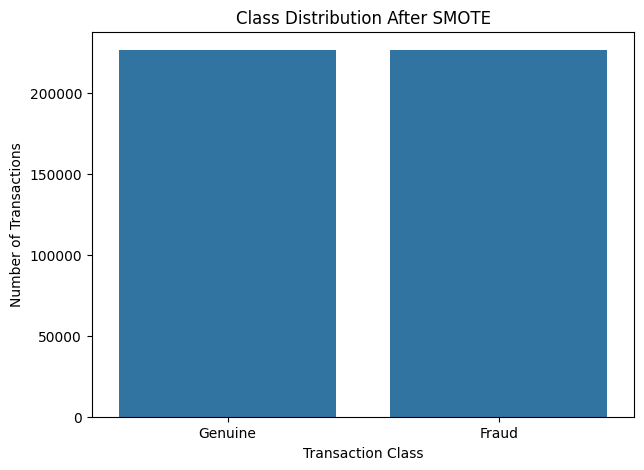

In [19]:
plt.figure(figsize=(7, 5))

sns.countplot(x=y_train_smote)

plt.title('Class Distribution After SMOTE')
plt.xlabel('Transaction Class')
plt.ylabel('Number of Transactions')
plt.xticks([0, 1], ['Genuine', 'Fraud'])

plt.show()

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Create Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train model
logistic_model.fit(X_train_smote, y_train_smote)

# Make predictions on original test data
y_pred_lr = logistic_model.predict(X_test)

# Prediction probabilities
y_prob_lr = logistic_model.predict_proba(X_test)[:, 1]

# Evaluation
print("Logistic Regression Results")
print("--------------------------------")
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_lr))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Results
--------------------------------
Accuracy : 0.9736721531033025
Precision: 0.053035143769968054
Recall   : 0.8736842105263158
F1 Score : 0.1
ROC-AUC  : 0.9618957810936585

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56651
           1       0.05      0.87      0.10        95

    accuracy                           0.97     56746
   macro avg       0.53      0.92      0.54     56746
weighted avg       1.00      0.97      0.99     56746



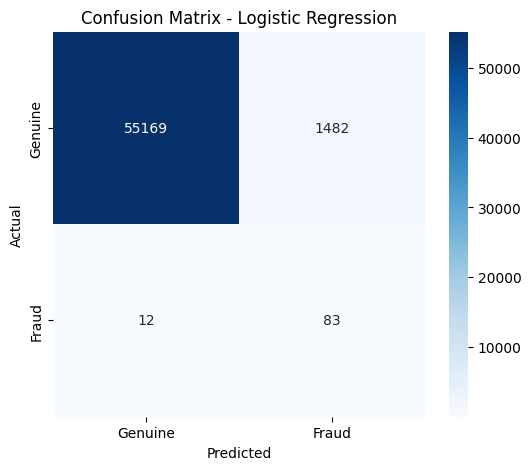

In [21]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Genuine', 'Fraud'],
    yticklabels=['Genuine', 'Fraud']
)

plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [23]:
from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree model
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=10
)

# Train model
dt_model.fit(X_train_smote, y_train_smote)

# Prediction
y_pred_dt = dt_model.predict(X_test)

# Probability
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

# Evaluation
print("Decision Tree Results")
print("---------------------")
print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_dt))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Results
---------------------
Accuracy : 0.9866422302893596
Precision: 0.09225092250922509
Recall   : 0.7894736842105263
F1 Score : 0.16519823788546256
ROC-AUC  : 0.8424413932396789

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.99      0.99     56651
           1       0.09      0.79      0.17        95

    accuracy                           0.99     56746
   macro avg       0.55      0.89      0.58     56746
weighted avg       1.00      0.99      0.99     56746



In [24]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

# Train model
rf_model.fit(X_train_smote, y_train_smote)

# Prediction
y_pred_rf = rf_model.predict(X_test)

# Prediction probability
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluation
print("Random Forest Results")
print("---------------------")
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Results
---------------------
Accuracy : 0.9985902090015155
Precision: 0.5547445255474452
Recall   : 0.8
F1 Score : 0.6551724137931034
ROC-AUC  : 0.976961896895953

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.55      0.80      0.66        95

    accuracy                           1.00     56746
   macro avg       0.78      0.90      0.83     56746
weighted avg       1.00      1.00      1.00     56746



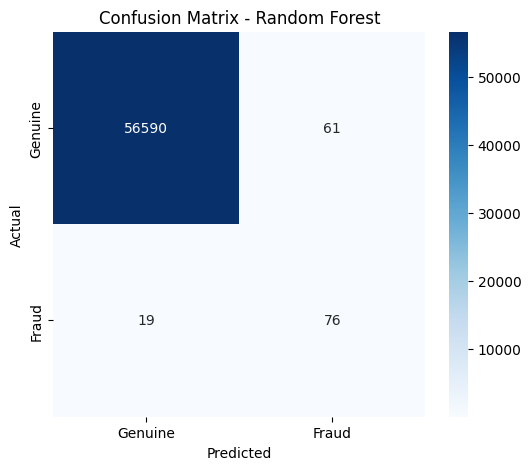

In [25]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Genuine', 'Fraud'],
    yticklabels=['Genuine', 'Fraud']
)

plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

In [26]:
model_comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf)
    ],
    'Precision': [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt),
        precision_score(y_test, y_pred_rf)
    ],
    'Recall': [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt),
        recall_score(y_test, y_pred_rf)
    ],
    'F1 Score': [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt),
        f1_score(y_test, y_pred_rf)
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

print(model_comparison)

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
0  Logistic Regression  0.973672   0.053035  0.873684  0.100000  0.961896
1        Decision Tree  0.986642   0.092251  0.789474  0.165198  0.842441
2        Random Forest  0.998590   0.554745  0.800000  0.655172  0.976962


In [27]:
# Feature Importance using Random Forest

feature_importance = pd.DataFrame({
    'Feature': X_train_smote.columns,
    'Importance': rf_model.feature_importances_
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

print("Top 15 Important Features:")
print(feature_importance.head(15))

Top 15 Important Features:
   Feature  Importance
14     V14    0.204866
10     V10    0.123509
12     V12    0.107269
17     V17    0.100200
4       V4    0.096954
11     V11    0.057615
16     V16    0.055708
3       V3    0.054981
2       V2    0.037707
9       V9    0.025079
21     V21    0.015431
7       V7    0.014356
8       V8    0.011757
18     V18    0.011684
27     V27    0.010331


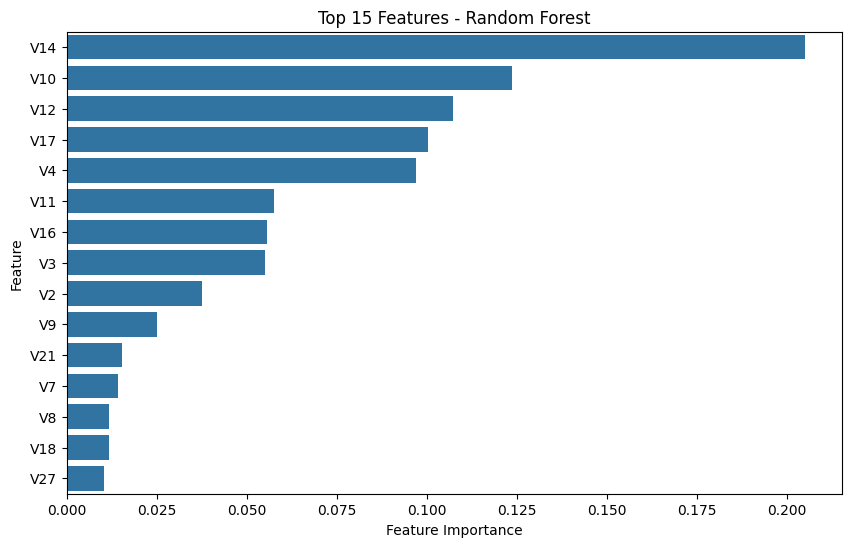

In [28]:
# Plot Top 15 Important Features

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

sns.barplot(
    x='Importance',
    y='Feature',
    data=top_features
)

plt.title('Top 15 Features - Random Forest')
plt.xlabel('Feature Importance')
plt.ylabel('Feature')

plt.show()

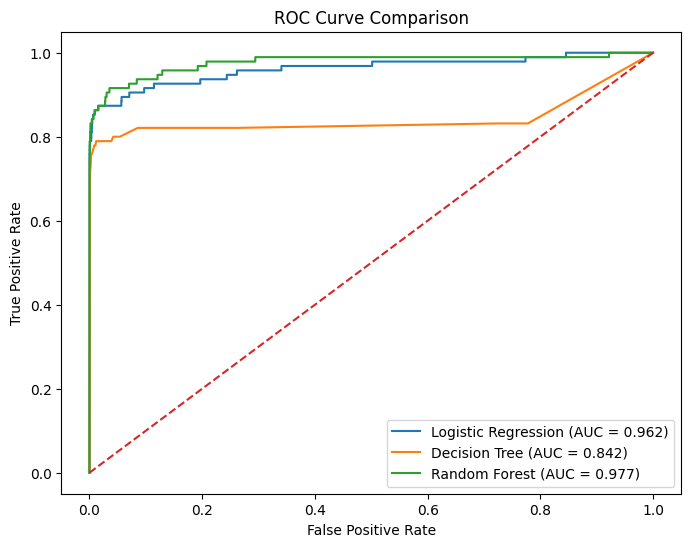

In [29]:
from sklearn.metrics import roc_curve

# ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f'Logistic Regression (AUC = {roc_auc_score(y_test, y_prob_lr):.3f})'
)

plt.plot(
    fpr_dt,
    tpr_dt,
    label=f'Decision Tree (AUC = {roc_auc_score(y_test, y_prob_dt):.3f})'
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f'Random Forest (AUC = {roc_auc_score(y_test, y_prob_rf):.3f})'
)

plt.plot([0, 1], [0, 1], linestyle='--')

plt.title('ROC Curve Comparison')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.show()

In [30]:
# Final Model Comparison

print("FINAL MODEL COMPARISON")
print("=" * 60)

display(
    model_comparison.style
    .format({
        'Accuracy': '{:.4f}',
        'Precision': '{:.4f}',
        'Recall': '{:.4f}',
        'F1 Score': '{:.4f}',
        'ROC-AUC': '{:.4f}'
    })
)

FINAL MODEL COMPARISON


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.9737,0.0530,0.8737,0.1000,0.9619
1,Decision Tree,0.9866,0.0923,0.7895,0.1652,0.8424
2,Random Forest,0.9986,0.5547,0.8000,0.6552,0.9770


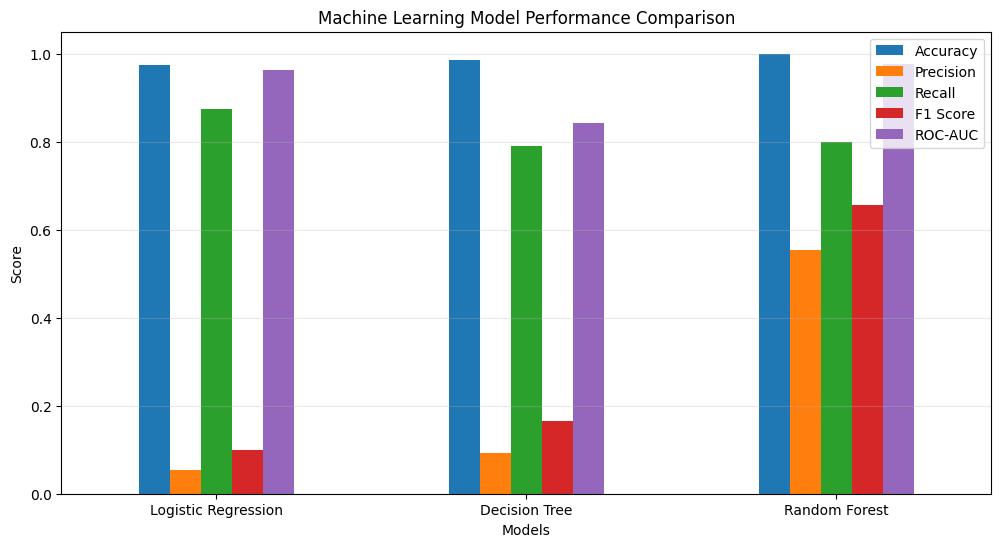

In [31]:
# Compare Model Performance

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']

model_comparison.set_index('Model')[metrics].plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title('Machine Learning Model Performance Comparison')
plt.xlabel('Models')
plt.ylabel('Score')
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend()
plt.grid(axis='y', alpha=0.3)

plt.show()

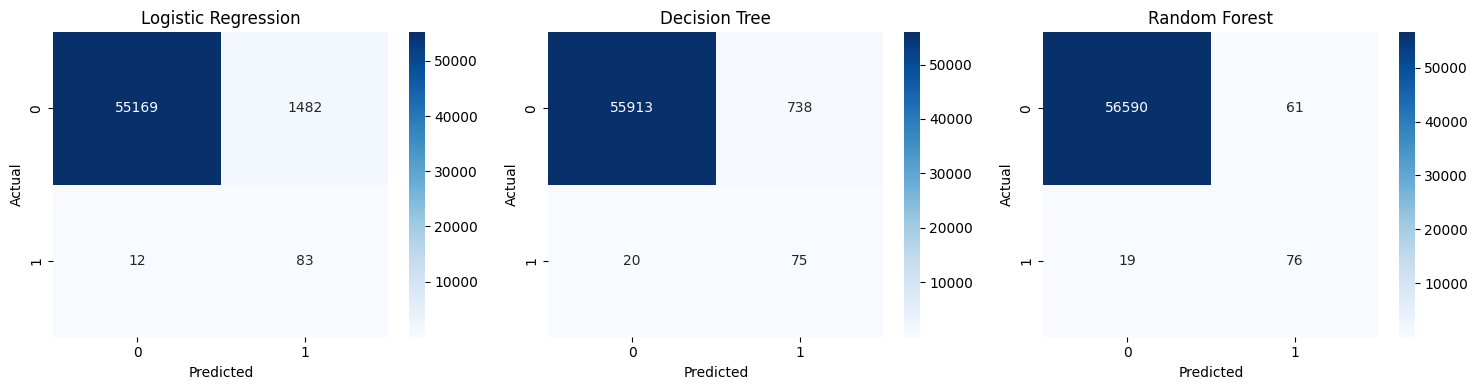

In [32]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Logistic Regression
sns.heatmap(
    confusion_matrix(y_test, y_pred_lr),
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[0]
)
axes[0].set_title('Logistic Regression')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# Decision Tree
sns.heatmap(
    confusion_matrix(y_test, y_pred_dt),
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[1]
)
axes[1].set_title('Decision Tree')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# Random Forest
sns.heatmap(
    confusion_matrix(y_test, y_pred_rf),
    annot=True,
    fmt='d',
    cmap='Blues',
    ax=axes[2]
)
axes[2].set_title('Random Forest')
axes[2].set_xlabel('Predicted')
axes[2].set_ylabel('Actual')

plt.tight_layout()
plt.show()

In [37]:
# Credit Card Fraud Prediction Function

def predict_transaction(transaction_data):

    # Convert input into DataFrame
    input_data = pd.DataFrame(
        [transaction_data],
        columns=X_train_smote.columns
    )

    # Scale Time and Amount
    input_data[['Time', 'Amount']] = scaler.transform(
        input_data[['Time', 'Amount']]
    )

    # Predict using Random Forest
    prediction = rf_model.predict(input_data)[0]
    probability = rf_model.predict_proba(input_data)[0][1]

    if prediction == 1:
        result = "FRAUD TRANSACTION"
    else:
        result = "GENUINE TRANSACTION"

    print("Prediction:", result)
    print("Fraud Probability:", round(probability * 100, 2), "%")

    return prediction

In [38]:
# Take one transaction from test dataset

sample_transaction = X_test.iloc[0].values

predict_transaction(sample_transaction)

Prediction: GENUINE TRANSACTION
Fraud Probability: 0.91 %


np.int64(0)

In [39]:
actual_class = y_test.iloc[0]
predicted_class = rf_model.predict(
    X_test.iloc[[0]]
)[0]

print("Actual Class   :", actual_class)
print("Predicted Class:", predicted_class)

if actual_class == predicted_class:
    print("Prediction: Correct")
else:
    print("Prediction: Incorrect")

Actual Class   : 0
Predicted Class: 0
Prediction: Correct


## Final Results

The project successfully developed Machine Learning models for
credit card fraud detection. Multiple classification algorithms
were trained and evaluated using Precision, Recall, F1-Score and
ROC-AUC along with confusion matrices.

## Conclusion

This project demonstrates how Machine Learning can be used to
detect fraudulent credit card transactions. SMOTE was used to
handle the highly imbalanced dataset, and multiple classification
models were evaluated to analyze their performance.

## Future Scope

- Real-time fraud detection
- Advanced Machine Learning algorithms
- Deep Learning models
- Real-time fraud alerts
- Web application deployment
- Continuous model retraining

# Thank You